# 02 · Build the first behavior tree

## Learning objectives

- Implement a status, a node, an action, and a condition.
- Build a two-step decision with ordinary Python.

**Environment:** the standalone Python kernel from the README. No ROS installation or sourcing is needed. Run all cells from top to bottom; each notebook starts with its own state.

## Intuition

Strings made the first example easy to read, but a typo could silently introduce a fourth
result. An **enumeration** gives us a closed vocabulary. A **node** needs a name, a last result,
and a way to tick. We will use a small class because state now has a clear owner.
A condition differs from an action in intent: it observes without changing the world.

## Minimal working example

In [2]:
from enum import Enum, auto

class Status(Enum):
    SUCCESS = auto()
    FAILURE = auto()
    RUNNING = auto()
    INVALID = auto()  # Visualization only: not yet visited.

class Node:
    def __init__(self, name, function):
        self.name, self.function = name, function
        self.status = Status.INVALID
        self.children = []

    def tick(self):
        self.status = self.function()
        return self.status

    def reset(self):
        self.status = Status.INVALID

# Actions and conditions use the same protocol; no extra subclasses are needed.
world = {"door_open": True, "inside": False}
condition = Node("Door open?", lambda: Status.SUCCESS if world["door_open"] else Status.FAILURE)

def enter():
    world["inside"] = True
    return Status.SUCCESS

action = Node("Enter", enter)
print(condition.tick(), action.tick(), world)

Status.SUCCESS Status.SUCCESS {'door_open': True, 'inside': True}


## Step-by-step implementation
A parent asks the condition first. It calls the action only if the condition succeeds.
The `children` list describes structure for drawing; the function determines execution.
This is the seed of a sequence, which we will generalize in lesson 3.

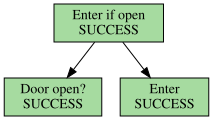

In [3]:
def guarded_entry():
    result = condition.tick()
    if result is not Status.SUCCESS:
        action.reset()
        return result
    return action.tick()

root = Node("Enter if open", guarded_entry)
root.children = [condition, action]
assert root.tick() is Status.SUCCESS
from behavior_trees_tutorial.visualization import diagram, trace, playground
from IPython.display import display
display(diagram(root))

## Interactive demonstration
Change the door and tick again. State belongs to this notebook, not a previous lesson.

In [4]:
import ipywidgets as widgets

@widgets.interact(door_open=True)
def try_entry(door_open=True):
    world.update(door_open=door_open, inside=False)
    root.tick()
    display(diagram(root))
    print(world)

interactive(children=(Checkbox(value=True, description='door_open'), Output()), _dom_classes=('widget-interact…

## Key observations

The protocol is tiny: ask for work, store the result, return it. A condition can fail without raising an exception.

## Exercises

1. Add a “Have key?” condition.
2. Ensure Enter is not called when the door is closed.

Hints and worked solutions: `exercises/README.md` and `solutions/README.md` (lesson 02).

## Summary

The tree structure makes a decision visible. Lesson 3 replaces one hardcoded parent with a reusable sequence rule.